Found 50 energy files between 1e+01 and 1e+06 GeV:
  E=1.12202e1 (1.122e+01 GeV)
  E=1.41254e1 (1.413e+01 GeV)
  E=1.77828e1 (1.778e+01 GeV)
  E=2.23872e1 (2.239e+01 GeV)
  E=2.81838e1 (2.818e+01 GeV)
  E=3.54813e1 (3.548e+01 GeV)
  E=4.46684e1 (4.467e+01 GeV)
  E=5.62341e1 (5.623e+01 GeV)
  E=7.07946e1 (7.079e+01 GeV)
  E=8.91251e1 (8.913e+01 GeV)
  E=1.12202e2 (1.122e+02 GeV)
  E=1.41254e2 (1.413e+02 GeV)
  E=1.77828e2 (1.778e+02 GeV)
  E=2.23872e2 (2.239e+02 GeV)
  E=2.81838e2 (2.818e+02 GeV)
  E=3.54813e2 (3.548e+02 GeV)
  E=4.46684e2 (4.467e+02 GeV)
  E=5.62341e2 (5.623e+02 GeV)
  E=7.07946e2 (7.079e+02 GeV)
  E=8.91251e2 (8.913e+02 GeV)
  E=1.12202e3 (1.122e+03 GeV)
  E=1.41254e3 (1.413e+03 GeV)
  E=1.77828e3 (1.778e+03 GeV)
  E=2.23872e3 (2.239e+03 GeV)
  E=2.81838e3 (2.818e+03 GeV)
  E=3.54813e3 (3.548e+03 GeV)
  E=4.46684e3 (4.467e+03 GeV)
  E=5.62341e3 (5.623e+03 GeV)
  E=7.07946e3 (7.079e+03 GeV)
  E=8.91251e3 (8.913e+03 GeV)
  E=1.12202e4 (1.122e+04 GeV)
  E=1.41254e4 (1.41

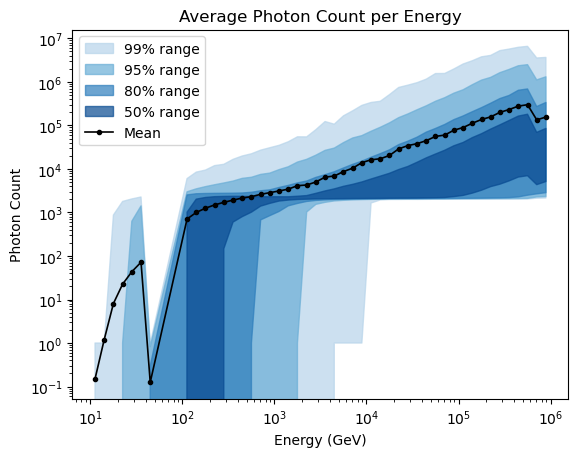

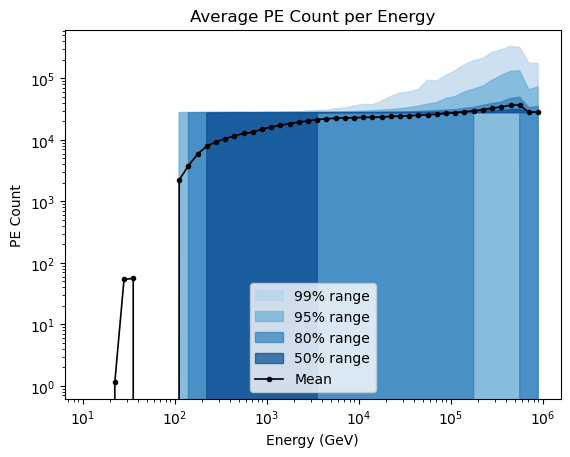

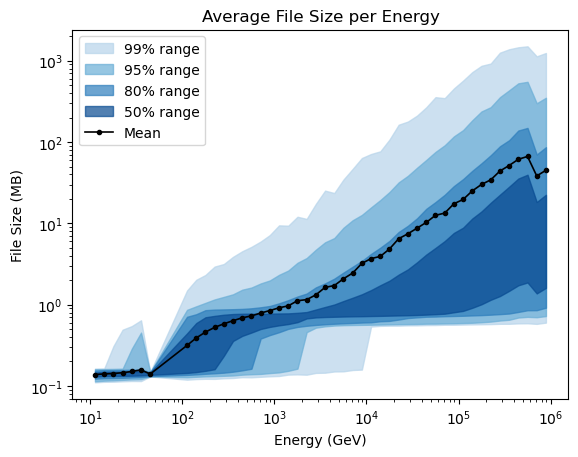

12.897803367917 TB 4304.663145085815 photon per MB


In [28]:
#Extract data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import sys
import math

# ── Configuration ─────────────────────────────────────────────────────────────
PE_THRESHOLD = 20
N_BOOTSTRAP = 1000
CI_LEVEL = 0.99
E_MIN_GEV = 1e1
E_MAX_GEV = 1e6
SEEDS = [1,2,3]
PID = 13
RADIUS = 5
BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"


# ── Helper functions ─────────────────────────────────────────────────────────
def load_scan(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    n_missing = (df["file_found"] == 0).sum()
    if n_missing > 0:
        print(f"  WARNING: {n_missing} rows had file_found=0 and will be dropped.")
        index = (df["file_found"] == 0)
        """print("zenith",set(df["zen"][index]))
        print("azimuth",set(df["az"][index]))
        print("height",set(df["height"][index]))"""
    df = df[df["file_found"] == 1].copy()
    df["r"] = np.sqrt(df["tel_x"]**2 + df["tel_z"]**2).round(4)
    df["detected"] = (df["max_pe"] >= PE_THRESHOLD).astype(float)
    return df

def slant_depth(zem, obs_height, zenith_rad):
    theta = np.pi - zenith_rad
    arg = (obs_height / zem) * np.sin(theta)
    arg = np.clip(arg, -1.0, 1.0)
    beta = np.where(np.isfinite(arg), np.arcsin(arg), 0.0)
    beta = np.clip(beta, 0.0, np.pi/2)
    #beta = np.clip(np.arcsin((obs_height / zem) * np.sin(theta)), 0, np.pi/2)
    alpha = np.pi - theta - beta
    s = zem * np.sin(alpha) / np.sin(theta)
    return np.clip(s, 0, np.inf)
def incidence_angle(Zenith_deg, Azimuth_deg):
    Zenith = Zenith_deg
    Azimuth = Azimuth_deg
    cos_Zenith = np.cos(np.radians(Zenith))
    cos_Azimuth = np.cos(np.radians(Azimuth - 180))
    cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
    Incidence = np.degrees(np.arccos(cos_Incidence))
    return Incidence
def bootstrap_trigger_rate(max_pe_in_bin, threshold, n_boot=N_BOOTSTRAP):
    alpha_ci = 1.0 - CI_LEVEL
    lo_pct = 100 * alpha_ci / 2
    hi_pct = 100 * (1 - alpha_ci / 2)
    n = len(max_pe_in_bin)
    if n == 0:
        return np.nan, np.nan, np.nan
    observed_rate = np.sum(max_pe_in_bin >= threshold) / n
    boot_rates = np.empty(n_boot)
    for b in range(n_boot):
        sample = np.random.choice(max_pe_in_bin, size=n, replace=True)
        boot_rates[b] = np.sum(sample >= threshold) / n
    ci_low = np.percentile(boot_rates, lo_pct)
    ci_high = np.percentile(boot_rates, hi_pct)
    return observed_rate, ci_low, ci_high

import re
import os

def get_available_energies(base_dir, pid, radius, e_min_GeV, e_max_GeV):
    """
    Scan BASE_DIR for folders matching the given PID and RADIUS,
    extract energy values, and filter by [e_min_GeV, e_max_GeV].
    Returns sorted list of (energy_GeV, energy_str) tuples.
    """
    pattern = re.compile(
        rf"Muon_pid{pid}_E([0-9]+\.?[0-9]*e[+-]?[0-9]+)_R{radius}$"
    )
    found = {}
    for name in os.listdir(base_dir):
        m = pattern.match(name)
        if m:
            energy_str = m.group(1)
            energy_val = float(energy_str)
            if e_min_GeV <= energy_val <= e_max_GeV:
                found[energy_val] = energy_str

    return sorted(found.items())  # sorted by energy_GeV


available = get_available_energies(BASE_DIR, PID, RADIUS, E_MIN_GEV, E_MAX_GEV)
print(f"Found {len(available)} energy files between {E_MIN_GEV:.0e} and {E_MAX_GEV:.0e} GeV:")
for e_val, e_str in available:
    print(f"  E={e_str} ({e_val:.3e} GeV)")

# ── Load only those files ────────────────────────────────────────────────────
dfs = []
missing_energies = []
for energy_val, energy_str in available:
    for seed in SEEDS:
        csv_path = (f"{BASE_DIR}/Muon_pid{PID}_E{energy_str}_R{RADIUS}/"
                    f"csv_output/scan_care_pid{PID}_E{energy_str}_R{RADIUS}_y0_s{seed}.csv")
        try:
            df_tmp = load_scan(csv_path)
            df_tmp["seed"] = seed
            df_tmp["energy_string"] = energy_str
            df_tmp["energy_GeV"] = energy_val
            dfs.append(df_tmp)
            print(f"  Loaded E={energy_str} seed={seed}: {len(df_tmp)} rows")
        except Exception as e:
            missing_energies.append(energy_str)
            print(f"  ⚠ E={energy_str} seed={seed}: {e}")


df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged: {len(df)} total rows from {len(dfs)} file(s)")
print(f"Energy range: {df['energy_GeV'].min():.1f} – {df['energy_GeV'].max():.1f} GeV")
if missing_energies:
    print(f"Missing energies: {sorted(set(missing_energies))}")

# ── Derived columns ──────────────────────────────────────────────────────────
R = np.array(df["r"])
X = np.array(df["tel_x"])
Z = np.array(df["tel_z"])
H = np.array(df["height"])
Zenith = np.array(df["zen"])
Azimuth = np.array(df["az"])
Max_PE = np.array(df["max_pe"])
Time_at_Max_PE = np.array(df["time_at_max_pe_ns"])
Avg_PE = np.array(df["avg_pe"])
Total_PE = np.array(df["total_pe"])
Energy_GeV = np.array(df["energy_GeV"])
Slant = slant_depth(H + 6371e3, 2944 + 6371e3, np.radians(Zenith))/1000 #km
cos_Zenith = np.cos(np.radians(Zenith))
cos_Azimuth = np.cos(np.radians(Azimuth - 180))
cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
Incidence = incidence_angle(Zenith, Azimuth)
#pulse_width = np.array(df["pulse_width_ns"])
#rise_time = np.array(df["rise_time_ns"])
x_mag = np.array(df["correction_x_m"])
y_mag = np.array(df["correction_y_m"])
file_size = np.array(df["file_size_MB"])
photon_count = np.array(df["cph_photon_count"])
max_photon_10ns = np.array(df["cph_max_photons_10ns"])
E_list = np.sort(np.array(list(set(Energy_GeV))))

File = []
Photon = []
PE = []

File_low, File_high = [], []
Photon_low, Photon_high = [], []
PE_low, PE_high = [], []

Total_FIle_Size = np.nansum(file_size)/1000 #MB to GB

# --- Coverage levels for nested bands ---
coverages = [50, 80, 95, 99]    # percent
cmap = plt.cm.Blues

# Storage for multi-coverage bands: dict[coverage] -> (lows, highs)
file_bands   = {c: ([], []) for c in coverages}
photon_bands = {c: ([], []) for c in coverages}
pe_bands     = {c: ([], []) for c in coverages}

for energy in E_list:
    mask = Energy_GeV == energy

    f  = np.nanmean(file_size[mask])
    p  = np.nanmean(photon_count[mask])
    pe = np.nanmean(Total_PE[mask])
    File.append(f)
    Photon.append(p)
    PE.append(pe)

    # 99% range (legacy)
    File_low.append(np.nanpercentile(file_size[mask], 0.5))
    File_high.append(np.nanpercentile(file_size[mask], 99.5))
    Photon_low.append(np.nanpercentile(photon_count[mask], 0.5))
    Photon_high.append(np.nanpercentile(photon_count[mask], 99.5))
    PE_low.append(np.nanpercentile(Total_PE[mask], 0.5))
    PE_high.append(np.nanpercentile(Total_PE[mask], 99.5))

    # Multi-coverage percentile bands
    for cov in coverages:
        lo_p = (100 - cov) / 2
        hi_p = 100 - lo_p
        file_bands[cov][0].append(np.nanpercentile(file_size[mask], lo_p))
        file_bands[cov][1].append(np.nanpercentile(file_size[mask], hi_p))
        photon_bands[cov][0].append(np.nanpercentile(photon_count[mask], lo_p))
        photon_bands[cov][1].append(np.nanpercentile(photon_count[mask], hi_p))
        pe_bands[cov][0].append(np.nanpercentile(Total_PE[mask], lo_p))
        pe_bands[cov][1].append(np.nanpercentile(Total_PE[mask], hi_p))

File   = np.array(File)
Photon = np.array(Photon)
PE     = np.array(PE)

File_low, File_high     = np.array(File_low),   np.array(File_high)
Photon_low, Photon_high = np.array(Photon_low), np.array(Photon_high)
PE_low, PE_high         = np.array(PE_low),     np.array(PE_high)

for cov in coverages:
    file_bands[cov]   = (np.array(file_bands[cov][0]),   np.array(file_bands[cov][1]))
    photon_bands[cov] = (np.array(photon_bands[cov][0]), np.array(photon_bands[cov][1]))
    pe_bands[cov]     = (np.array(pe_bands[cov][0]),     np.array(pe_bands[cov][1]))


def plot_with_bands(E_list, mean, bands_dict, coverages, ylabel, title):
    fig, ax = plt.subplots()
    # Widest first (lightest), narrowest last (darkest)
    order = sorted(coverages, reverse=True)
    n = len(order)
    for i, cov in enumerate(order):
        lo, hi = bands_dict[cov]
        color = cmap(0.3 + 0.6 * (i / max(1, n - 1)))
        ax.fill_between(E_list, lo, hi, color=color, alpha=0.7,
                        label=f'{cov}% range')
    ax.plot(E_list, mean, 'k.-', lw=1.2, label='Mean')
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()


# --- Photon Count Plot ---
plot_with_bands(E_list, Photon, photon_bands, coverages,
                "Photon Count", "Average Photon Count per Energy")

# --- PE Count Plot ---
plot_with_bands(E_list, PE, pe_bands, coverages,
                "PE Count", "Average PE Count per Energy")

plot_with_bands(E_list, File, file_bands, coverages,
                "File Size (MB)", "Average File Size per Energy")

print(Total_FIle_Size/1000, "TB", np.nanmean(Photon)/np.nanmean(File), "photon per MB")


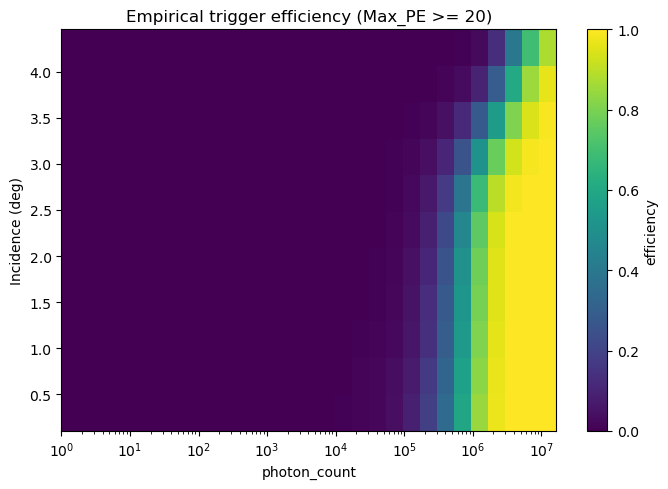

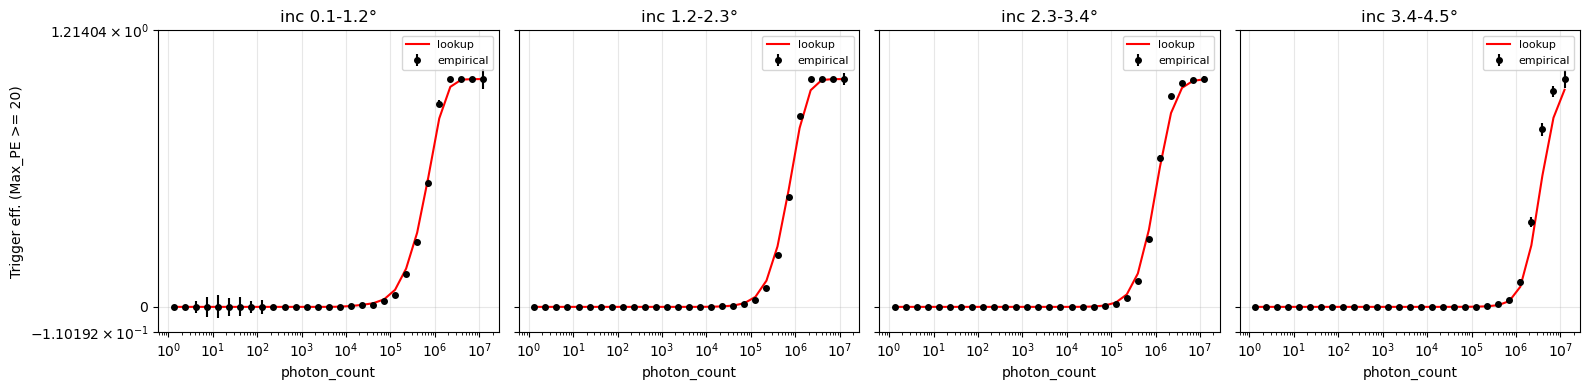

In [29]:
# Empirical trigger efficiency: P(Max_PE >= threshold | photon_count, incidence)
# =============================================================================
from scipy.ndimage import gaussian_filter

# ---------- 1. Clean inputs ----------
m = (np.isfinite(photon_count) & (photon_count > 0)
     & np.isfinite(Max_PE)     & (Max_PE >= 0)
     & np.isfinite(Incidence))
pc_  = photon_count[m]
pe_  = Max_PE[m]
inc_ = Incidence[m]
hit_ = (pe_ >= PE_THRESHOLD).astype(float)

# ---------- 2. Define 2-D bins ----------
pc_edges  = np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 30)
inc_edges = np.linspace(inc_.min(),inc_.max(), 12)
pc_cen    = np.sqrt(pc_edges[:-1] * pc_edges[1:])
inc_cen   = 0.5*(inc_edges[:-1] + inc_edges[1:])

# ---------- 3. Build empirical efficiency table ----------
N_tot, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges])
N_hit, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges], weights=hit_)

with np.errstate(invalid='ignore', divide='ignore'):
    eff = np.where(N_tot >= 5, N_hit / N_tot, np.nan)
    eff_err = np.where(N_tot >= 5, np.sqrt(eff*(1-eff)/N_tot), np.nan)

# Light smoothing to fill noisy bins (optional)
eff_smooth = eff.copy()
mask = np.isfinite(eff_smooth)
eff_smooth[~mask] = 0
weights = mask.astype(float)
eff_smooth = gaussian_filter(eff_smooth, sigma=0.8) / np.clip(
    gaussian_filter(weights, sigma=0.8), 1e-6, None)

# ---------- 4. Lookup function with bilinear interpolation ----------
from scipy.interpolate import RegularGridInterpolator
interp = RegularGridInterpolator(
    (np.log10(pc_cen), inc_cen), eff_smooth,
    bounds_error=False, fill_value=None, method='linear')

def trigger_eff(N_gamma, inc_deg):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)
    pts = np.column_stack([
        np.log10(np.clip(N_b.ravel(), pc_.min(), pc_.max())),
        np.clip(inc_b.ravel(), inc_.min(), inc_.max()),
    ])
    vals = np.clip(interp(pts), 0.0, 1.0)
    return vals.reshape(N_b.shape)

# ---------- 5. Plot the efficiency map ----------
fig, ax = plt.subplots(figsize=(7,5))
pcm = ax.pcolormesh(pc_edges, inc_edges, eff_smooth.T,
                    cmap='viridis', vmin=0, vmax=1, shading='auto')
ax.set_xscale('log')
ax.set_xlabel("photon_count"); ax.set_ylabel("Incidence (deg)")
ax.set_title(f"Empirical trigger efficiency (Max_PE >= {PE_THRESHOLD})")
plt.colorbar(pcm, ax=ax, label='efficiency')
plt.tight_layout(); plt.show()

# ---------- 6. Slice validation ----------
bounds = np.linspace(inc_.min(), inc_.max(), 5)
slices = list(zip(bounds[:-1], bounds[1:]))
fig, axes = plt.subplots(1, len(slices), figsize=(4*len(slices), 4), sharey=True)
for ax, (ilo, ihi) in zip(axes, slices):
    sel = (inc_ >= ilo) & (inc_ < ihi)
    emp, err = [], []
    for i in range(len(pc_cen)):
        s2 = sel & (pc_ >= pc_edges[i]) & (pc_ < pc_edges[i+1])
        n = s2.sum()
        if n >= 5:
            p = np.mean(hit_[s2]); emp.append(p)
            err.append(np.sqrt(p*(1-p)/n) + 1.0/n)
        else:
            emp.append(np.nan); err.append(np.nan)
    emp, err = np.array(emp), np.array(err)
    pred = trigger_eff(pc_cen, 0.5*(ilo+ihi))
    ax.errorbar(pc_cen, emp, yerr=err, fmt='ko', ms=4, label='empirical')
    ax.plot(pc_cen, pred, 'r-', label='lookup')
    ax.set_xscale('log')#; ax.set_ylim(-0.05, 1.1)
    ax.set_yscale('symlog')
    ax.set_xlabel("photon_count")
    ax.set_title(f"inc {ilo:.1f}-{ihi:.1f}°")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
plt.tight_layout(); plt.show()


In [31]:
# Bootstrap uncertainty for the empirical trigger efficiency lookup
# =============================================================================
N_BOOT   = 200      # number of bootstrap replicas
CI_LEVEL = 99.0     # percent (68 = 1-sigma-like, 95 = 2-sigma-like)

rng = np.random.default_rng(0)

def build_interp(pc_s, inc_s, hit_s):
    """Build a RegularGridInterpolator from one (resampled) dataset."""
    N_tot, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges])
    N_hit, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges],
                                 weights=hit_s)
    with np.errstate(invalid='ignore', divide='ignore'):
        e = np.where(N_tot >= 5, N_hit / N_tot, np.nan)

    mask = np.isfinite(e)
    e_filled = np.where(mask, e, 0.0)
    w = mask.astype(float)
    e_smooth = gaussian_filter(e_filled, sigma=0.8) / np.clip(
        gaussian_filter(w, sigma=0.8), 1e-6, None)

    return RegularGridInterpolator(
        (np.log10(pc_cen), inc_cen), e_smooth,
        bounds_error=False, fill_value=None, method='linear')

# ---------- Bootstrap replicas ----------
n = len(pc_)
boot_interps = []
for b in range(N_BOOT):
    idx = rng.integers(0, n, size=n)
    boot_interps.append(build_interp(pc_[idx], inc_[idx], hit_[idx]))
    if (b + 1) % 50 == 0:
        print(f"  bootstrap {b+1}/{N_BOOT}")

# ---------- Efficiency with uncertainty ----------
alpha = (100.0 - CI_LEVEL) / 2.0

def trigger_eff_ci(N_gamma, inc_deg):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)

    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)
    pts = np.column_stack([
        np.log10(np.clip(N_b.ravel(), pc_.min(), pc_.max())),
        np.clip(inc_b.ravel(), inc_.min(), inc_.max()),
    ])

    nominal = np.clip(interp(pts), 0.0, 1.0)
    samples = np.array([np.clip(bi(pts), 0.0, 1.0) for bi in boot_interps])
    lo = np.percentile(samples, alpha,       axis=0)
    hi = np.percentile(samples, 100 - alpha, axis=0)

    return (
        nominal.reshape(N_b.shape),
        lo.reshape(N_b.shape),
        hi.reshape(N_b.shape),
    )




  bootstrap 50/200
  bootstrap 100/200
  bootstrap 150/200
  bootstrap 200/200


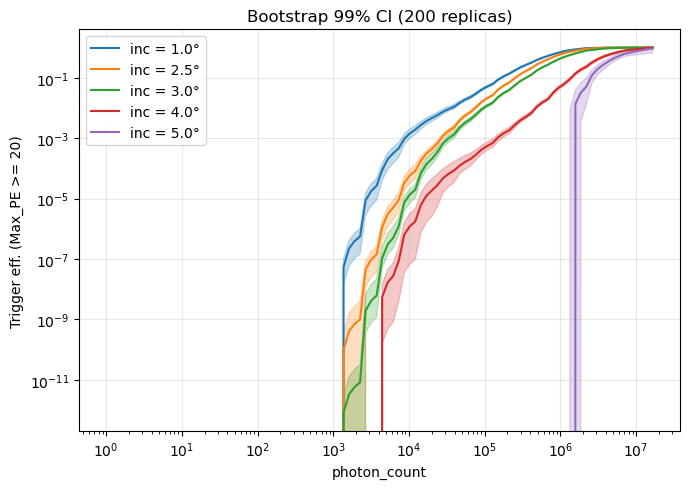

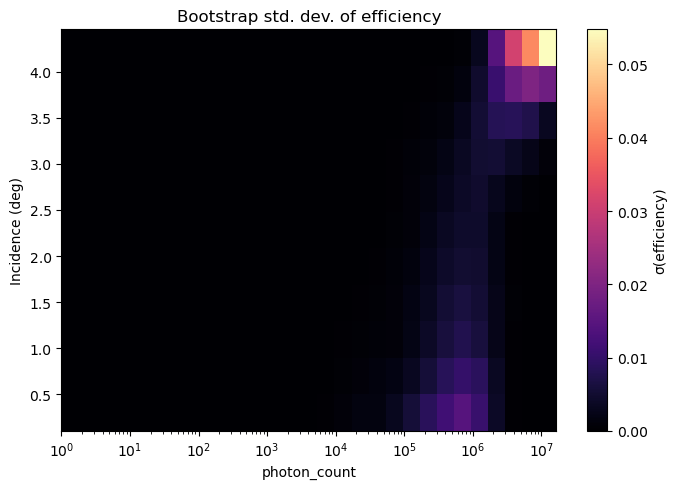

In [32]:
# ---------- Example: efficiency vs photon_count at a few incidences ----------
fig, ax = plt.subplots(figsize=(7, 5))
N_grid = np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 100)
for inc_val, color in zip([1.0, 2.5, 3, 4.0, 5.0], ['C0', 'C1', 'C2', 'C3', 'C4']):
    eff_c, lo, hi = trigger_eff_ci(N_grid, inc_val)
    ax.plot(N_grid, eff_c, color=color, label=f"inc = {inc_val:.1f}°")
    ax.fill_between(N_grid, lo, hi, color=color, alpha=0.25)
ax.set_xscale('log')#; ax.set_ylim(-0.05, 1.1)
ax.set_yscale('log')
ax.set_xlabel("photon_count")
ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
ax.set_title(f"Bootstrap {CI_LEVEL:.0f}% CI ({N_BOOT} replicas)")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# ---------- Uncertainty map ----------
samples_grid = np.array([
    np.clip(bi(np.column_stack([
        np.log10(np.repeat(pc_cen, len(inc_cen))),
        np.tile(inc_cen, len(pc_cen))
    ])), 0.0, 1.0).reshape(len(pc_cen), len(inc_cen))
    for bi in boot_interps
])
eff_std = samples_grid.std(axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
pcm = ax.pcolormesh(pc_edges, inc_edges, eff_std.T,
                    cmap='magma', shading='auto')
ax.set_xscale('log')
ax.set_xlabel("photon_count"); ax.set_ylabel("Incidence (deg)")
ax.set_title("Bootstrap std. dev. of efficiency")
plt.colorbar(pcm, ax=ax, label='σ(efficiency)')
plt.tight_layout(); plt.show()


In [42]:
# Empirical efficiency cube on (zenith, H, E) with slant extrapolation (v3 style)
# =============================================================================
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt
from functools import lru_cache

BOOT_SEED = 123
N_BOOT_EFF = 200
MIN_PTS_EFF = 5
N_E_BINS = 30
N_H_BINS = 20
N_Z_BINS = 20
N_AZ_BINS = 20
# Set these to extend the grid beyond data for extrapolation
ZEN_MIN = 80 #np.nanmin(Zenith)
ZEN_MAX = 92 #np.nanmax(Zenith)

H_MIN = 2944.0
H_MAX = 100000
OBS_HEIGHT_M = 2944.0
EARTH_RADIUS_M = 6_371_000.0

# No parametric gradients in v4 lookup; keep placeholders for sigma_fit
N_PARAMS = 1
PARAM_ORDER = ["dummy"]
COV_FULL = np.zeros((N_PARAMS, N_PARAMS))


def _sigma_from_grad(grad):
    grad = np.asarray(grad, dtype=float)
    var = np.einsum('...i,ij,...j->...', grad, COV_FULL, grad)
    return np.sqrt(np.maximum(var, 0.0))


def eff_vs_zenith_vectorized(N_arr, theta_z_arr, psi_deg,
                             phi_max_deg=3.0, n_phi=100,
                             paired=False):
    """
    Azimuth-averaged efficiency using v4 trigger_eff.
    """
    phi = np.linspace(0.0, np.radians(phi_max_deg), n_phi)
    theta_z = np.radians(np.asarray(theta_z_arr, dtype=float))
    N_arr = np.asarray(N_arr, dtype=float)
    psi = np.radians(float(psi_deg))

    if paired:
        if N_arr.shape != theta_z.shape:
            raise ValueError("paired=True requires N_arr and theta_z_arr to have the same shape")
        cos_theta = (
            np.cos(psi) * np.cos(theta_z)[:, np.newaxis]
            + np.sin(psi) * np.sin(theta_z)[:, np.newaxis] * np.cos(phi)[np.newaxis, :]
        )
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta_inc = np.degrees(np.arccos(cos_theta))
        N_2d = N_arr[:, np.newaxis]
        eff_vals = trigger_eff(N_2d, theta_inc)
        avg = np.trapezoid(eff_vals, phi, axis=-1) / (phi[-1] - phi[0])
        return avg

    cos_theta = (
        np.cos(psi) * np.cos(theta_z)[:, np.newaxis]
        + np.sin(psi) * np.sin(theta_z)[:, np.newaxis] * np.cos(phi)[np.newaxis, :]
    )
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta_inc = np.degrees(np.arccos(cos_theta))

    N_3d = N_arr[:, np.newaxis, np.newaxis]
    theta_3d = theta_inc[np.newaxis, :, :]
    eff_vals = trigger_eff(N_3d, theta_3d)

    avg = np.trapezoid(eff_vals, phi, axis=-1) / (phi[-1] - phi[0])
    return avg.T


def eff_vs_zenith_with_gradients(N_arr, theta_z_arr, psi_deg,
                                 phi_max_deg=3.0, n_phi=100,
                                 paired=False):
    eff = eff_vs_zenith_vectorized(
        N_arr, theta_z_arr, psi_deg, phi_max_deg, n_phi, paired
    )
    if paired:
        grad = np.zeros((eff.shape[0], N_PARAMS))
        return eff, grad
    grad = np.zeros((eff.shape[0], eff.shape[1], N_PARAMS))
    return eff, grad


@lru_cache(maxsize=None)
def _eff_cached(N_int, zenith_tuple, psi_deg, phi_max_deg, n_phi):
    pc = np.array([N_int], dtype=float)
    zen = np.array(zenith_tuple, dtype=float)
    return eff_vs_zenith_vectorized(pc, zen, psi_deg, phi_max_deg, n_phi, paired=False)[:, 0]


@lru_cache(maxsize=None)
def _eff_grad_cached(N_int, zenith_tuple, psi_deg, phi_max_deg, n_phi):
    pc = np.array([N_int], dtype=float)
    zen = np.array(zenith_tuple, dtype=float)
    _, grad = eff_vs_zenith_with_gradients(pc, zen, psi_deg, phi_max_deg, n_phi, paired=False)
    return grad[:, 0, :]


def _bootstrap_sigma(eff_vals, reducer, n_boot=200, rng=None):
    eff_vals = np.asarray(eff_vals, dtype=float)
    if rng is None:
        rng = np.random.default_rng()
    if eff_vals.ndim == 1:
        n_pc = eff_vals.shape[0]
        if n_pc == 0:
            return np.nan
        idx = rng.integers(0, n_pc, size=(n_boot, n_pc))
        boot = eff_vals[idx]
        boot_stat = reducer(boot, axis=1)
        return np.std(boot_stat, ddof=1)
    if eff_vals.ndim == 2:
        n_zen, n_pc = eff_vals.shape
        if n_pc == 0:
            return np.full(n_zen, np.nan)
        idx = rng.integers(0, n_pc, size=(n_boot, n_pc))
        boot = eff_vals[:, idx]
        boot_stat = reducer(boot, axis=2)
        return np.std(boot_stat, axis=1, ddof=1)
    raise ValueError("eff_vals must be 1D or 2D")


# =========================================================================
# 3. Empirical efficiency cube on (zenith, H, E)
# =========================================================================
def efficiency_grid_H_E(E_edges, H_edges, zenith_deg,
                        Energy_GeV, H_emit, photon_count,
                        psi_deg=90.0, phi_max_deg=3.0, n_phi=20,
                        min_pts=5, reduce='mean', n_boot=200, rng=None):
    """
    Bin CORSIKA showers in (E, H), compute optical efficiency per bin.
    """
    E_edges = np.asarray(E_edges, dtype=float)
    H_edges = np.asarray(H_edges, dtype=float)
    zenith_deg = np.atleast_1d(np.asarray(zenith_deg, dtype=float))

    Energy_GeV = np.asarray(Energy_GeV, dtype=float)
    H_emit = np.asarray(H_emit, dtype=float)
    photon_count = np.asarray(photon_count, dtype=float)

    n_E = len(E_edges) - 1
    n_H = len(H_edges) - 1
    n_zen = len(zenith_deg)

    EFF = np.full((n_zen, n_H, n_E), np.nan)
    STD = np.full((n_zen, n_H, n_E), np.nan)
    GRAD = np.full((n_zen, n_H, n_E, N_PARAMS), np.nan)
    SIG_SCATTER = np.full((n_zen, n_H, n_E), np.nan)
    COUNTS = np.zeros((n_H, n_E), dtype=int)

    E_cen = np.sqrt(E_edges[:-1] * E_edges[1:])
    H_cen = 0.5 * (H_edges[:-1] + H_edges[1:])

    reducer = np.mean if reduce == 'mean' else np.median
    if rng is None:
        rng = np.random.default_rng()

    pc_in_bin = [[None] * n_E for _ in range(n_H)]
    zen_tuple = tuple(zenith_deg)

    for i in range(n_E):
        in_E = (Energy_GeV >= E_edges[i]) & (Energy_GeV < E_edges[i + 1])
        for j in range(n_H):
            mask = in_E & (H_emit >= H_edges[j]) & (H_emit < H_edges[j + 1])
            pc = photon_count[mask]
            pc = pc[np.isfinite(pc) & (pc > 0)]
            COUNTS[j, i] = len(pc)
            pc_in_bin[j][i] = pc

            if len(pc) < min_pts:
                continue

            eff_vals, grad_vals = eff_vs_zenith_with_gradients(
                pc, zenith_deg, psi_deg, phi_max_deg, n_phi, paired=False
            )

            EFF[:, j, i] = reducer(eff_vals, axis=1)
            STD[:, j, i] = np.std(eff_vals, axis=1)
            GRAD[:, j, i, :] = reducer(grad_vals, axis=1)
            SIG_SCATTER[:, j, i] = _bootstrap_sigma(eff_vals, reducer, n_boot=n_boot, rng=rng)

    SIG_FIT = _sigma_from_grad(GRAD)
    SIG_TOTAL = np.sqrt(SIG_FIT**2 + SIG_SCATTER**2)

    COUNTS_3d = np.broadcast_to(COUNTS[np.newaxis, :, :], (n_zen, n_H, n_E)).copy()

    return EFF, STD, COUNTS_3d, E_cen, H_cen, pc_in_bin, GRAD, SIG_FIT, SIG_SCATTER, SIG_TOTAL


# =========================================================================
# 4. Build (E, Slant) photon-count lookup table
# =========================================================================
def build_E_slant_pc_table(E_edges, H_emit, Energy_GeV, photon_count,
                           Zenith_deg, n_slant_bins):
    E_edges = np.asarray(E_edges, dtype=float)
    H_emit = np.asarray(H_emit, dtype=float)
    Energy_GeV = np.asarray(Energy_GeV, dtype=float)
    photon_count = np.asarray(photon_count, dtype=float)
    Zenith_rad = np.radians(np.asarray(Zenith_deg, dtype=float))

    Slant_km = slant_depth(
        H_emit + EARTH_RADIUS_M,
        OBS_HEIGHT_M + EARTH_RADIUS_M,
        Zenith_rad,
    ) / 1000.0

    S_edges = np.linspace(np.nanmin(Slant_km), np.nanmax(Slant_km), n_slant_bins + 1)
    S_cen = 0.5 * (S_edges[:-1] + S_edges[1:])

    n_E = len(E_edges) - 1
    pc_ES = [[None] * n_slant_bins for _ in range(n_E)]

    for i in range(n_E):
        in_E = (Energy_GeV >= E_edges[i]) & (Energy_GeV < E_edges[i + 1])
        for s in range(n_slant_bins):
            mask = in_E & (Slant_km >= S_edges[s]) & (Slant_km < S_edges[s + 1])
            pc = photon_count[mask]
            pc = pc[np.isfinite(pc) & (pc > 0)]
            pc_ES[i][s] = pc

    return S_edges, S_cen, pc_ES


# =========================================================================
# 5. Slant-based extrapolation
# =========================================================================
def extrapolate_via_slant(
    EFF,
    GRAD,
    SIG_SCATTER,
    E_cen,
    H_cen,
    zenith_deg,
    S_edges,
    pc_ES,
    psi_deg=90.0,
    phi_max_deg=5.0,
    n_phi=20,
    min_pts=5,
    reduce='mean',
    n_boot=200,
    rng=None,
    ):
    reducer = np.mean if reduce == 'mean' else np.median
    if rng is None:
        rng = np.random.default_rng()

    n_zen, n_H, n_E = EFF.shape

    for k in range(n_zen):
        zen = zenith_deg[k]
        zen_tuple = (zen,)

        for j in range(n_H):
            slant_km = (
                slant_depth(
                    H_cen[j] + EARTH_RADIUS_M,
                    OBS_HEIGHT_M + EARTH_RADIUS_M,
                    np.deg2rad(zen),
                ) / 1000.0
            )

            si = np.searchsorted(S_edges, slant_km) - 1
            si = int(np.clip(si, 0, len(S_edges) - 2))

            for i in range(n_E):
                if np.isfinite(EFF[k, j, i]):
                    continue

                pc = pc_ES[i][si]
                if pc is None or len(pc) < min_pts:
                    continue

                eff_vals, grad_vals = eff_vs_zenith_with_gradients(
                    pc, np.array([zen], dtype=float), psi_deg, phi_max_deg, n_phi, paired=False
                )
                eff_vals = eff_vals[0]
                grad_vals = grad_vals[0]

                if len(eff_vals):
                    EFF[k, j, i] = reducer(eff_vals)
                    GRAD[k, j, i, :] = reducer(grad_vals, axis=0)
                    SIG_SCATTER[k, j, i] = _bootstrap_sigma(
                        eff_vals, reducer, n_boot=n_boot, rng=rng
                    )

    return EFF, GRAD, SIG_SCATTER


# =========================================================================
# 6. Build efficiency interpolator
# =========================================================================
def build_efficiency_interpolator(
    EFF,
    GRAD,
    SIG_SCATTER,
    E_cen,
    H_cen,
    zenith_deg,
    S_edges,
    pc_ES,
    psi_deg=90.0,
    phi_max_deg=5.0,
    n_phi=20,
    min_pts=3,
    reduce='mean',
    n_boot=200,
    rng=None,
    # NEW: extend grid outward for extrapolation
    H_extrap_range=(0.0, 120_000.0),
    n_H_extra=4,
    zen_extrap_range=None,   # e.g. (80.0, 95.0); None = keep zenith axis as is
    n_zen_extra=2,
    ):

    # -----------------------------------------------------------------
    # 0. Extend the (zenith, H) axes outward and embed the input cube
    # -----------------------------------------------------------------
    H_cen = np.asarray(H_cen, dtype=float)
    zenith_deg = np.asarray(zenith_deg, dtype=float)

    if n_H_extra > 0:
        H_lo_new = np.linspace(H_extrap_range[0], H_cen[0],  n_H_extra + 1)[:-1]
        H_hi_new = np.linspace(H_cen[-1], H_extrap_range[1], n_H_extra + 1)[1:]
        H_cen_ext = np.concatenate([H_lo_new, H_cen, H_hi_new])
    else:
        H_cen_ext = H_cen.copy()

    if zen_extrap_range is not None and n_zen_extra > 0:
        Z_lo = np.linspace(zen_extrap_range[0], zenith_deg[0],  n_zen_extra + 1)[:-1]
        Z_hi = np.linspace(zenith_deg[-1], zen_extrap_range[1], n_zen_extra + 1)[1:]
        zen_ext = np.concatenate([Z_lo, zenith_deg, Z_hi])
    else:
        zen_ext = zenith_deg.copy()

    z_off = int(np.searchsorted(zen_ext, zenith_deg[0]))
    h_off = int(np.searchsorted(H_cen_ext, H_cen[0]))
    n_zen_ext = len(zen_ext)
    n_H_ext = len(H_cen_ext)
    n_E = EFF.shape[2]

    def _embed(arr_old):
        if arr_old.ndim == 4:
            out = np.full((n_zen_ext, n_H_ext, n_E, arr_old.shape[-1]),
                          np.nan, dtype=float)
            out[z_off:z_off + len(zenith_deg),
                h_off:h_off + len(H_cen), :, :] = arr_old
        else:
            out = np.full((n_zen_ext, n_H_ext, n_E), np.nan, dtype=float)
            out[z_off:z_off + len(zenith_deg),
                h_off:h_off + len(H_cen), :] = arr_old
        return out

    EFF         = _embed(EFF)
    GRAD        = _embed(GRAD)
    SIG_SCATTER = _embed(SIG_SCATTER)

    # From here on, use the extended axes
    H_cen = H_cen_ext
    zenith_deg = zen_ext

    # -----------------------------------------------------------------
    # 1. Original pipeline (unchanged below)
    # -----------------------------------------------------------------
    EFF_filled = EFF.copy()
    GRAD_filled = GRAD.copy()
    SIG_SCATTER_filled = SIG_SCATTER.copy()

    fill_mask = ~np.isfinite(EFF)

    nan_mask = ~np.isfinite(EFF_filled)
    if np.any(nan_mask):
        _, idx = distance_transform_edt(nan_mask, return_indices=True)
        nearest_vals = EFF_filled[tuple(idx)]
        nearest_grad = GRAD_filled[tuple(idx)]
        nearest_scatter = SIG_SCATTER_filled[tuple(idx)]

        EFF_filled[nan_mask] = nearest_vals[nan_mask]
        GRAD_filled[nan_mask] = nearest_grad[nan_mask]
        SIG_SCATTER_filled[nan_mask] = nearest_scatter[nan_mask]

    original_nan = ~np.isfinite(EFF)
    edge_mask = np.zeros_like(EFF_filled, dtype=bool)
    edge_mask[:, :2, :] = True
    edge_mask[:2, :, :] = True
    edge_mask[-2:, :, :] = True

    reopen = edge_mask & original_nan
    EFF_filled[reopen] = np.nan
    GRAD_filled[reopen] = np.nan
    SIG_SCATTER_filled[reopen] = np.nan

    EFF_filled, GRAD_filled, SIG_SCATTER_filled = extrapolate_via_slant(
        EFF_filled,
        GRAD_filled,
        SIG_SCATTER_filled,
        E_cen,
        H_cen,
        zenith_deg,
        S_edges,
        pc_ES,
        psi_deg=psi_deg,
        phi_max_deg=phi_max_deg,
        n_phi=n_phi,
        min_pts=min_pts,
        reduce=reduce,
        n_boot=n_boot,
        rng=rng,
    )

    remaining_nan = ~np.isfinite(EFF_filled)
    if np.any(remaining_nan):
        _, idx2 = distance_transform_edt(remaining_nan, return_indices=True)
        nearest_vals2 = EFF_filled[tuple(idx2)]
        nearest_grad2 = GRAD_filled[tuple(idx2)]
        nearest_scatter2 = SIG_SCATTER_filled[tuple(idx2)]

        EFF_filled[remaining_nan] = nearest_vals2[remaining_nan]
        GRAD_filled[remaining_nan] = nearest_grad2[remaining_nan]
        SIG_SCATTER_filled[remaining_nan] = nearest_scatter2[remaining_nan]

    EFF_filled[~np.isfinite(EFF_filled)] = 0.0
    GRAD_filled[~np.isfinite(GRAD_filled)] = 0.0
    SIG_SCATTER_filled[~np.isfinite(SIG_SCATTER_filled)] = 0.0

    SIG_FIT_filled = _sigma_from_grad(GRAD_filled)
    SIG_TOTAL_filled = np.sqrt(SIG_FIT_filled**2 + SIG_SCATTER_filled**2)

    log10_E = np.log10(E_cen)

    rgi_eff = RegularGridInterpolator(
        (zenith_deg, H_cen, log10_E),
        EFF_filled,
        method='linear',
        bounds_error=False,
        fill_value=None,
    )

    rgi_grad = RegularGridInterpolator(
        (zenith_deg, H_cen, log10_E),
        GRAD_filled,
        method='linear',
        bounds_error=False,
        fill_value=None,
    )

    rgi_scatter = RegularGridInterpolator(
        (zenith_deg, H_cen, log10_E),
        SIG_SCATTER_filled,
        method='linear',
        bounds_error=False,
        fill_value=None,
    )

    mask_float = fill_mask.astype(float)
    rgi_mask = RegularGridInterpolator(
        (zenith_deg, H_cen, log10_E),
        mask_float,
        method='nearest',
        bounds_error=False,
        fill_value=1.0,
    )

    def eff_func(E_GeV, H_m, zenith_deg_q):
        E_GeV = np.asarray(E_GeV, dtype=float)
        H_m = np.asarray(H_m, dtype=float)
        zenith_deg_q = np.asarray(zenith_deg_q, dtype=float)

        E_b, H_b, Z_b = np.broadcast_arrays(E_GeV, H_m, zenith_deg_q)
        pts = np.column_stack([
            Z_b.ravel(),
            H_b.ravel(),
            np.log10(E_b.ravel()),
        ])
        vals = rgi_eff(pts)
        vals = np.clip(vals, 0.0, 1.0)
        return vals.reshape(E_b.shape)

    def eff_sigma_func(E_GeV, H_m, zenith_deg_q):
        E_GeV = np.asarray(E_GeV, dtype=float)
        H_m = np.asarray(H_m, dtype=float)
        zenith_deg_q = np.asarray(zenith_deg_q, dtype=float)

        E_b, H_b, Z_b = np.broadcast_arrays(E_GeV, H_m, zenith_deg_q)
        pts = np.column_stack([
            Z_b.ravel(),
            H_b.ravel(),
            np.log10(E_b.ravel()),
        ])

        grad_vals = rgi_grad(pts)
        sigma_fit = _sigma_from_grad(grad_vals)
        sigma_scatter = rgi_scatter(pts)
        sigma_total = np.sqrt(sigma_fit**2 + sigma_scatter**2)
        return sigma_total.reshape(E_b.shape)

    def eff_fill_mask_func(E_GeV, H_m, zenith_deg_q):
        E_GeV = np.asarray(E_GeV, dtype=float)
        H_m = np.asarray(H_m, dtype=float)
        zenith_deg_q = np.asarray(zenith_deg_q, dtype=float)

        E_b, H_b, Z_b = np.broadcast_arrays(E_GeV, H_m, zenith_deg_q)
        pts = np.column_stack([
            Z_b.ravel(),
            H_b.ravel(),
            np.log10(E_b.ravel()),
        ])

        mask_vals = rgi_mask(pts)
        return (mask_vals.reshape(E_b.shape) >= 0.5)

    extra = {
        "EFF_filled": EFF_filled,
        "sigma_fit": SIG_FIT_filled,
        "sigma_scatter": SIG_SCATTER_filled,
        "sigma_total": SIG_TOTAL_filled,
        "fill_mask": fill_mask,
        "param_order": PARAM_ORDER,
        "H_cen_ext": H_cen,
        "zen_ext": zenith_deg,
    }

    return eff_func, eff_sigma_func, eff_fill_mask_func, extra



def ffill_along_H(EFF, *extras):
    n_zen, n_H, n_E = EFF.shape
    out = EFF.copy()
    extra_outs = [arr.copy() for arr in extras]
    for k in range(n_zen):
        for i in range(n_E):
            col = out[k, :, i]
            finite = np.isfinite(col)
            if not finite.any():
                continue
            idx = np.where(finite, np.arange(n_H), 0)
            np.maximum.accumulate(idx, out=idx)
            out[k, :, i] = col[idx]
            for arr_out in extra_outs:
                arr_out[k, :, i, ...] = arr_out[k, idx, i, ...]
    if extra_outs:
        return (out, *extra_outs)
    return out


# =========================================================================
# Build efficiency interpolator
# =========================================================================
rng = np.random.default_rng(BOOT_SEED)
E_edges = np.logspace(np.log10(Energy_GeV.min()), np.log10(Energy_GeV.max()), N_E_BINS + 1)
H_edges = np.linspace(H_MIN, H_MAX, N_H_BINS + 1)
Zen_grid = np.linspace(ZEN_MIN, ZEN_MAX, N_Z_BINS)

EFF, STD, COUNTS, E_cen, H_cen, pc_in_bin, GRAD, SIG_FIT, SIG_SCATTER, SIG_TOTAL = efficiency_grid_H_E(
    E_edges, H_edges, Zen_grid,
    Energy_GeV, H, photon_count,
    psi_deg=90.0, phi_max_deg=5.0, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reduce='mean',
    n_boot=N_BOOT_EFF, rng=rng,
 )

EFF, GRAD, SIG_SCATTER = ffill_along_H(EFF, GRAD, SIG_SCATTER)

S_edges, S_cen, pc_ES = build_E_slant_pc_table(
    E_edges, H, Energy_GeV, photon_count, Zenith,
    n_slant_bins=N_H_BINS,
 )

eff_func, eff_sigma_func, eff_fill_mask_func, eff_extra = build_efficiency_interpolator(
    EFF,
    GRAD,
    SIG_SCATTER,
    E_cen,
    H_cen,
    Zen_grid,
    S_edges,
    pc_ES,
    psi_deg=90.0, phi_max_deg=5.0, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reduce='mean',
    n_boot=N_BOOT_EFF, rng=rng,
 )




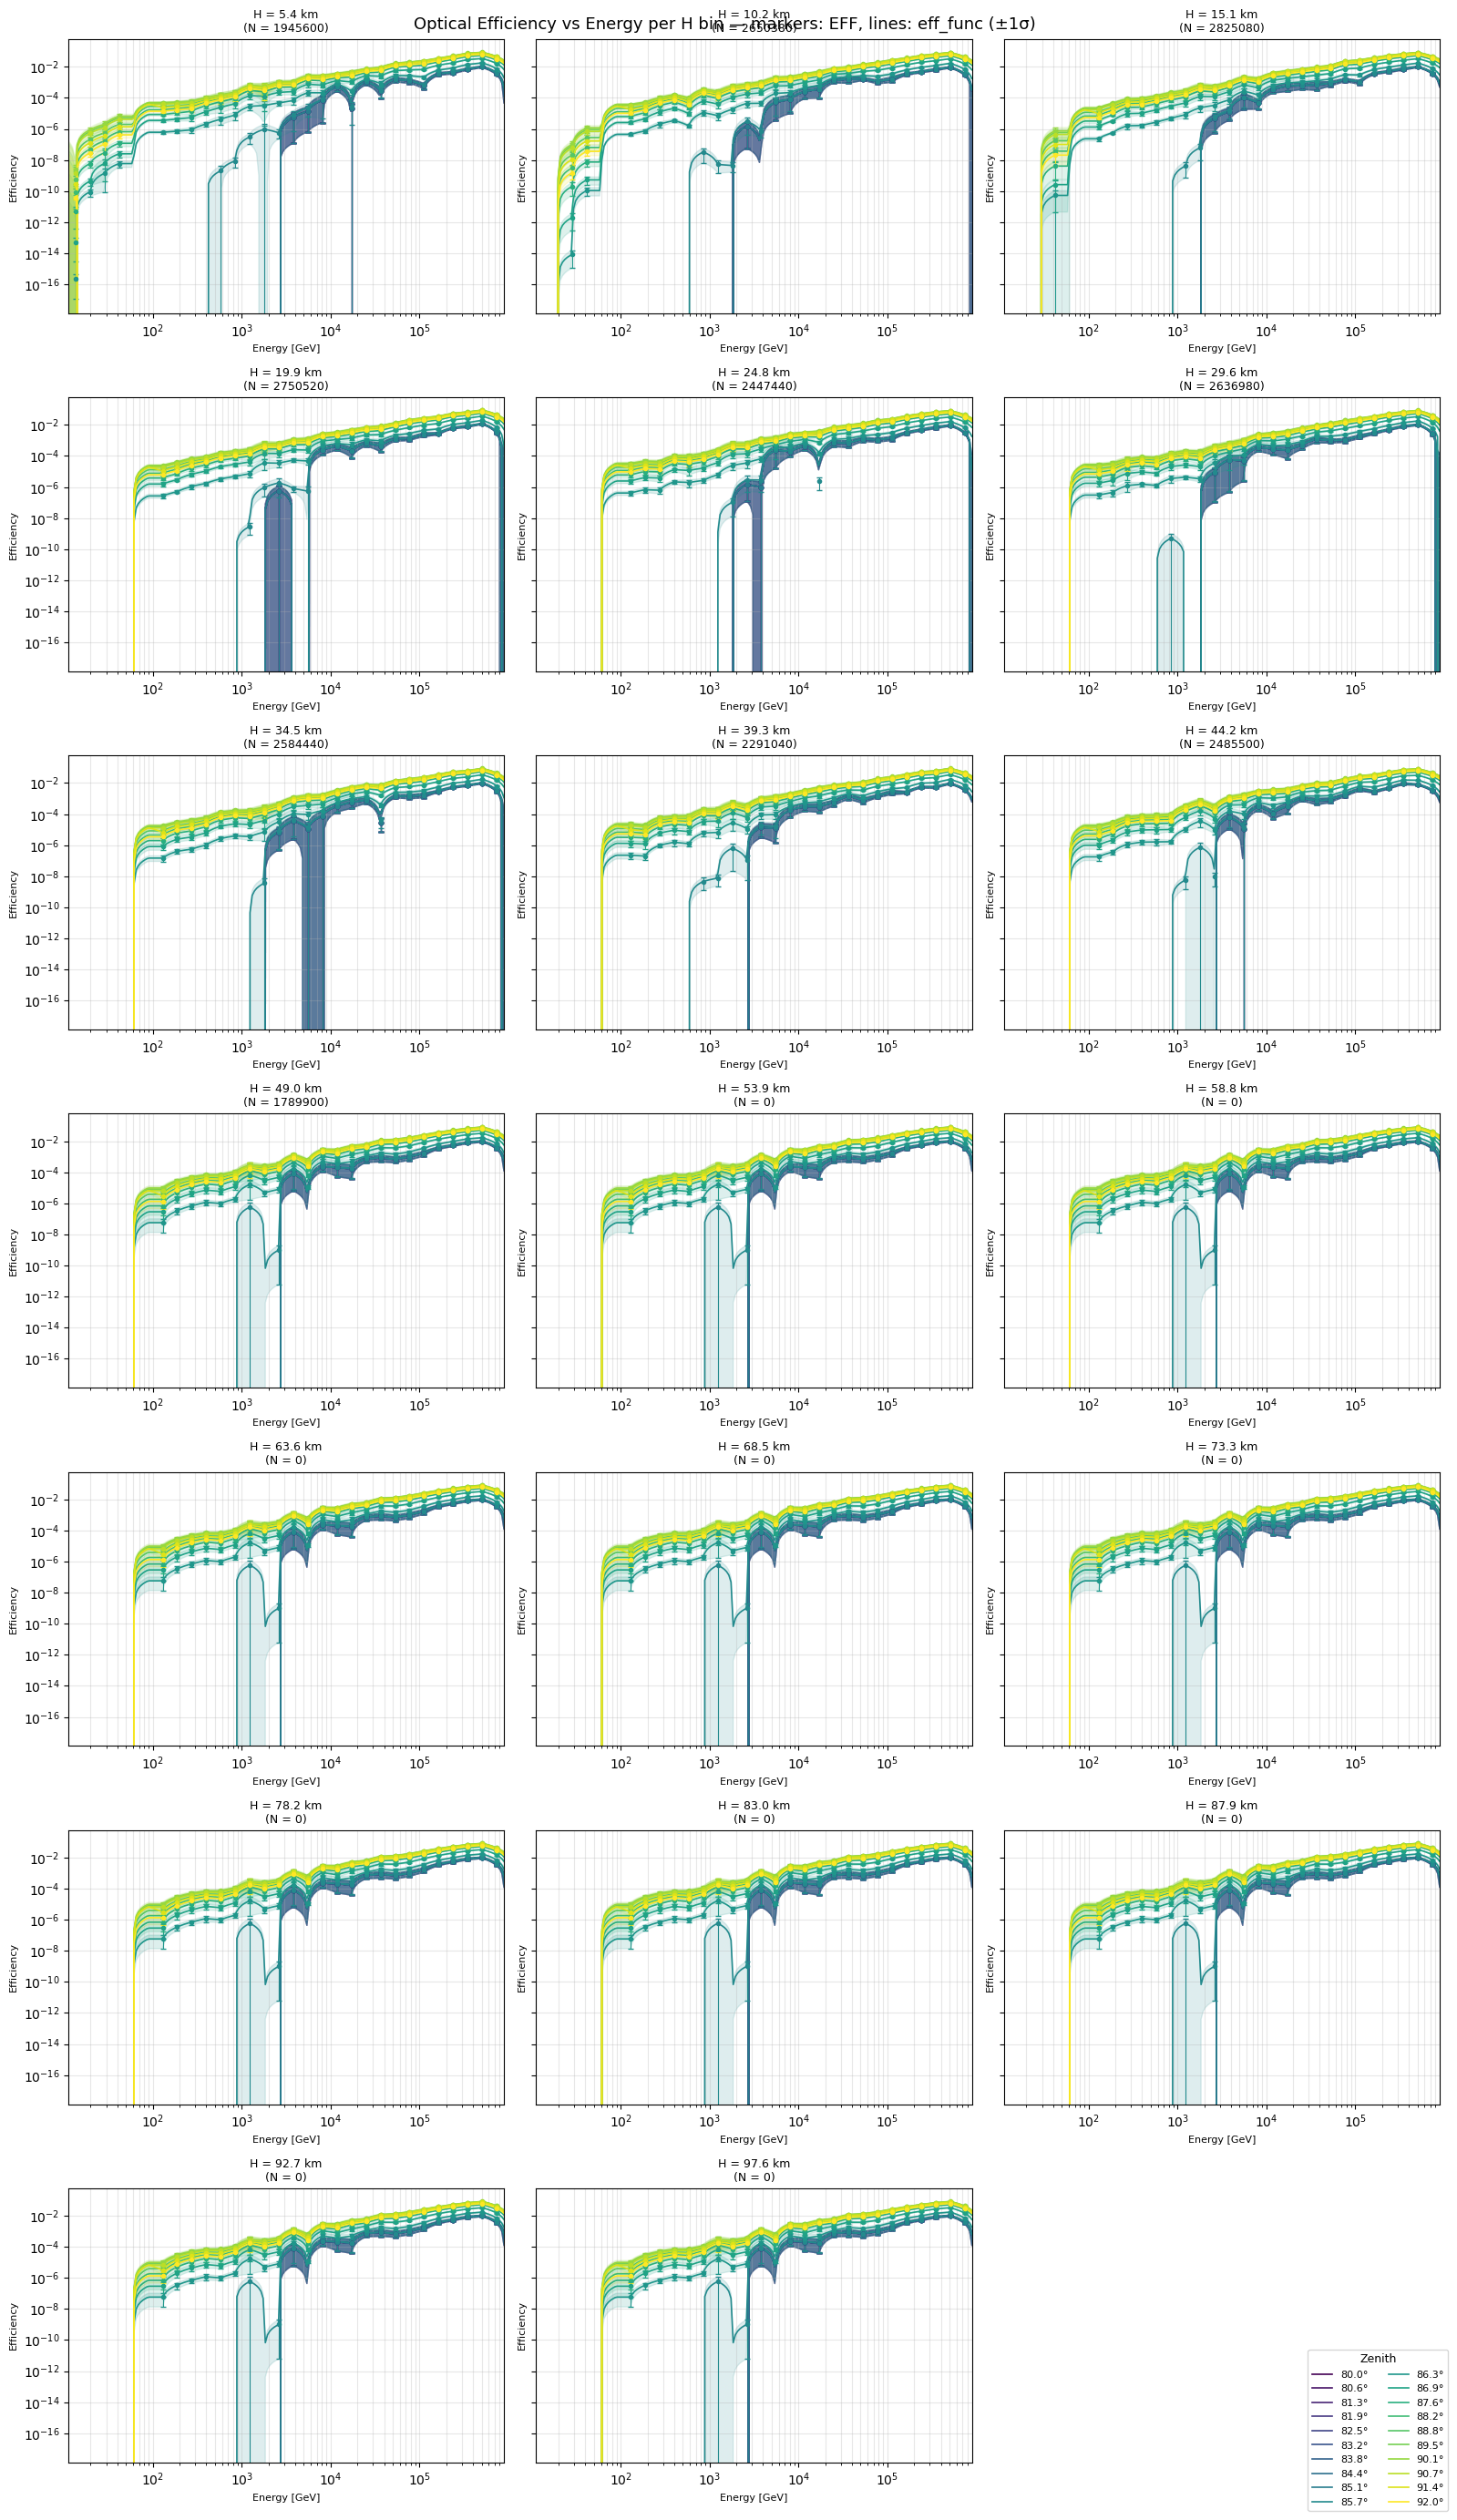

In [43]:
#Testing plot
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

n_H = len(H_cen)
n_Z = len(Zen_grid)

ncols = 3
nrows = int(np.ceil(n_H / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(16, 4 * nrows),
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

colors = cm.viridis(np.linspace(0, 1, n_Z))

# dense E axis for smooth interpolator curves
E_plot = np.logspace(np.log10(E_edges[0]), np.log10(E_edges[-1]), 200)

for j in range(n_H):
    ax = axes[j]
    H_val = H_cen[j]

    for k, zen in enumerate(Zen_grid):
        # --- interpolator (smooth line) ---
        eff_curve = eff_func(
            E_plot,
            np.full_like(E_plot, H_val),
            np.full_like(E_plot, zen),
        )
        sig_curve = eff_sigma_func(
            E_plot,
            np.full_like(E_plot, H_val),
            np.full_like(E_plot, zen),
        )

        ax.plot(
            E_plot, eff_curve,
            color=colors[k],
            linestyle='-',
            linewidth=1.2,
            label=f"{zen:.1f}°",
        )
        lo = np.clip(eff_curve - sig_curve, 0.0, 1.0)
        hi = np.clip(eff_curve + sig_curve, 0.0, 1.0)
        ax.fill_between(E_plot, lo, hi, color=colors[k], alpha=0.15)

        # --- raw EFF with error bars (markers) ---
        eff_row = EFF[k, j, :]
        valid = np.isfinite(eff_row)
        if valid.any():
            eff_sigma_pts = eff_sigma_func(
                E_cen[valid],
                np.full_like(E_cen[valid], H_val),
                np.full_like(E_cen[valid], zen),
            )
            ax.errorbar(
                E_cen[valid], eff_row[valid],
                yerr=eff_sigma_pts,
                color=colors[k],
                marker='o',
                markersize=3,
                linestyle='none',
                elinewidth=0.8,
                capsize=2,
            )

    ax.set_xscale('log')
    ax.set_xlim(E_edges[0], E_edges[-1])
    ax.set_yscale("log")
    ax.set_title(
        f"H = {H_cen[j]/1e3:.1f} km\n"
        f"(N = {COUNTS[:, j, :].sum()})",
        fontsize=9,
    )
    ax.set_xlabel("Energy [GeV]", fontsize=8)
    ax.set_ylabel("Efficiency",   fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Zenith",
    loc='lower right',
    ncol=2,
    fontsize=8,
    title_fontsize=9,
    bbox_to_anchor=(1.0, 0.0),
)

for j in range(n_H, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Optical Efficiency vs Energy per H bin — markers: EFF, lines: eff_func (±1σ)",
             fontsize=13)
plt.tight_layout()
plt.show()


In [44]:
#FLux Calculation
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# =========================================================================
# Use the efficiency interpolator built in Cell 5
# =========================================================================
if "eff_func" not in globals() or "eff_sigma_func" not in globals():
    raise RuntimeError("Run Cell 5 to build the efficiency cube and interpolators.")

# Optional fill-mask helper (tracks which cells were originally NaN)
log10_E = np.log10(E_cen)
fill_mask = ~np.isfinite(EFF)

rgi_mask = RegularGridInterpolator(
    (Zen_grid, H_cen, log10_E),
    fill_mask.astype(float),
    method='nearest',
    bounds_error=False,
    fill_value=1.0,
)

def eff_fill_mask_func(E_GeV, H_m, zenith_deg_q):
    E_GeV = np.asarray(E_GeV, dtype=float)
    H_m = np.asarray(H_m, dtype=float)
    zenith_deg_q = np.asarray(zenith_deg_q, dtype=float)
    E_b, H_b, Z_b = np.broadcast_arrays(E_GeV, H_m, zenith_deg_q)
    pts = np.column_stack([
        Z_b.ravel(),
        H_b.ravel(),
        np.log10(E_b.ravel()),
    ])
    mask_vals = rgi_mask(pts)
    return (mask_vals.reshape(E_b.shape) >= 0.5)

print("eff(E=1e4 GeV, H=8 km, zen=87 deg) =", eff_func(1e4, 8000.0, 87.0))
print("sigma_eff(E=1e4 GeV, H=8 km, zen=87 deg) =", eff_sigma_func(1e4, 8000.0, 87.0))
print("filled(E=1e4 GeV, H=8 km, zen=87 deg) =", eff_fill_mask_func(1e4, 8000.0, 87.0))


eff(E=1e4 GeV, H=8 km, zen=87 deg) = 0.0009568880919187983
sigma_eff(E=1e4 GeV, H=8 km, zen=87 deg) = 0.0002649844856720572
filled(E=1e4 GeV, H=8 km, zen=87 deg) = False


Extending from largest zenith 89.9503° up to 92.0°
Total zenith bins after extension: 120 (range 91.950° → 80.051°)


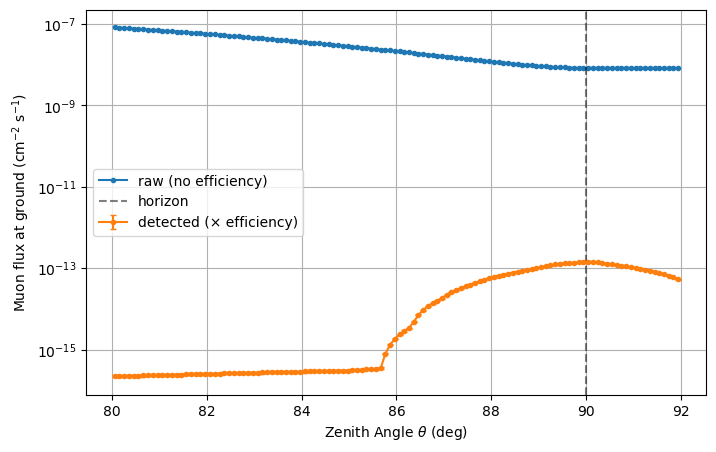

Effective Area (cm^2): 462351.73996121046
Detected muons per hour: 0.007682085097201907 +/- 2.37388933258321e-05
Total muons per hour: 5983.347295416906


In [45]:
#Extrapolate to high zenith
import pickle
# =========================================================================
# 2. Load the precomputed MCEq grid
# =========================================================================
with open('/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/'
          'mceq_grid_80_90deg.pkl', 'rb') as f:
    grid_data = pickle.load(f)

zen_centers_all = grid_data['zen_centers']
cos_edges       = grid_data['cos_edges']
E_GeV           = grid_data['E_GeV']
min_E           = grid_data['min_E']
max_E           = grid_data['max_E']

# --- User-selected zenith window (deg) ---
zen_min_use, zen_max_use = 80, 90.0

zen_mask = (zen_centers_all >= zen_min_use) & (zen_centers_all <= zen_max_use)
if not np.any(zen_mask):
    raise ValueError(
        f"No zenith bins in [{zen_min_use}, {zen_max_use}] deg. "
        f"Available centers: {zen_centers_all}"
    )

zen_centers = zen_centers_all[zen_mask]

# --- Azimuth / solid angle settings ---
min_az, max_az = 260, 270
dphi = np.radians(max_az - min_az)
dcos = np.diff(cos_edges)
solid_angles_all = dphi * np.abs(dcos)
solid_angles     = solid_angles_all[zen_mask]

selected_entries = [e for e, keep in zip(grid_data['per_zenith'], zen_mask) if keep]

# =========================================================================
# 2b. EXTEND to 92° using the largest-zenith MCEq flux (assumed constant)
# =========================================================================
extend_to_deg   = 92.0
extra_bin_width = 0.1  # deg, width of each synthetic zenith bin beyond 90°

# Pick the entry with the LARGEST zenith (closest to horizon)
idx_max = int(np.argmax(zen_centers))
last_entry = selected_entries[idx_max]
last_theta = last_entry['theta']
print(f"Extending from largest zenith {last_theta:.4f}° up to {extend_to_deg}°")

# Build extra zenith centers from (last_theta + dz) up to extend_to_deg
extra_centers = np.arange(last_theta + extra_bin_width,
                          extend_to_deg + 1e-9,
                          extra_bin_width)

# Solid angle for each extra bin: dphi * |cos(th-dz/2) - cos(th+dz/2)|
extra_solid_angles = []
for zc in extra_centers:
    c_lo = np.cos(np.radians(zc - extra_bin_width/2))
    c_hi = np.cos(np.radians(zc + extra_bin_width/2))
    extra_solid_angles.append(dphi * abs(c_lo - c_hi))
extra_solid_angles = np.array(extra_solid_angles)

# Append synthetic entries (copy of last entry, just relabel theta)
for zc in extra_centers:
    synth = {
        'theta'   : zc,
        'd_CDF'   : last_entry['d_CDF'],
        'H_grid'  : last_entry['H_grid'],
        'sum_mceq': last_entry['sum_mceq'],
    }
    selected_entries.append(synth)

# Build synthetic MCEq entries reusing the largest-zenith data
extra_entries = []
for zc in extra_centers:
    extra_entries.append({
        'theta':    zc,
        'd_CDF':    last_entry['d_CDF'],
        'H_grid':   last_entry['H_grid'],
        'sum_mceq': last_entry['sum_mceq'],
    })

# After building extra_centers, extra_solid_angles, extra_entries:
zen_centers      = np.concatenate([zen_centers, extra_centers])
solid_angles     = np.concatenate([solid_angles, extra_solid_angles])
selected_entries = selected_entries + extra_entries

# Sort descending (to match original convention) — optional
order = np.argsort(zen_centers)[::-1]
zen_centers      = zen_centers[order]
solid_angles     = solid_angles[order]
selected_entries = [selected_entries[i] for i in order]

print(f"Total zenith bins after extension: {len(zen_centers)} "
      f"(range {zen_centers[0]:.3f}° → {zen_centers[-1]:.3f}°)")

# =========================================================================
# 3. Loop over zenith and apply efficiency via eff_func
# =========================================================================
Total_flux_raw       = []
Total_flux_detected2 = []
Total_flux_detected2_err = []
eff_map = []
eff_map_err = []

for i, entry in enumerate(selected_entries):
    theta    = entry['theta']
    d_CDF    = entry['d_CDF']
    H_grid   = entry['H_grid']
    sum_mceq = entry['sum_mceq']
    H_m = H_grid / 100.0
    Solid_angle = solid_angles[i]

    # eff_func: clamp zenith query to max available in Zen_grid
    theta_q = min(theta, Zen_grid[-1])

    H_mesh, E_mesh = np.meshgrid(H_m, E_GeV, indexing='ij')
    Z_mesh = np.full_like(H_mesh, theta_q)
    eff_HE2 = eff_func(E_mesh, H_mesh, Z_mesh)
    eff_HE2 = np.nan_to_num(eff_HE2, nan=0.0)
    eff_sigma_HE2 = eff_sigma_func(E_mesh, H_mesh, Z_mesh)
    eff_sigma_HE2 = np.nan_to_num(eff_sigma_HE2, nan=0.0)

    E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)

    CDF = np.cumsum(d_CDF, axis=0)
    CDF_positive = np.cumsum(np.clip(d_CDF, 0, None), axis=0)
    survival_prob_per_E = CDF[-1] / CDF_positive[-1]

    integrand_HE2 = np.clip(d_CDF, 0, None) * eff_HE2 * survival_prob_per_E
    d_CDF_det_E   = np.trapezoid(integrand_HE2[:, E_mask], E_GeV[E_mask], axis=1)
    detected_at_ground2 = np.cumsum(d_CDF_det_E, axis=0)[-1]

    integrand_sigma = np.clip(d_CDF, 0, None) * eff_sigma_HE2 * survival_prob_per_E
    d_CDF_det_E_sigma = np.trapezoid(integrand_sigma[:, E_mask], E_GeV[E_mask], axis=1)
    sigma_detected_at_ground2 = np.sqrt(np.sum(d_CDF_det_E_sigma**2))

    weights = survival_prob_per_E * np.clip(d_CDF, 0, None)
    weight_sum = weights.sum(axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        eff_vs_E = np.where(
            weight_sum > 0,
            (weights * eff_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )
        w_norm = np.where(weight_sum > 0, weights / weight_sum, 0.0)
        eff_vs_E_sigma = np.where(
            weight_sum > 0,
            np.sqrt(np.sum((w_norm * eff_sigma_HE2) ** 2, axis=0)),
            np.nan,
        )

    cos_factor = 1
    Total_flux_raw.append(      sum_mceq            * Solid_angle * cos_factor)
    Total_flux_detected2.append(detected_at_ground2 * Solid_angle * cos_factor)
    Total_flux_detected2_err.append(sigma_detected_at_ground2 * Solid_angle * cos_factor)
    eff_map.append(eff_vs_E)
    eff_map_err.append(eff_vs_E_sigma)

Total_flux_raw       = np.array(Total_flux_raw)
Total_flux_detected2 = np.array(Total_flux_detected2)
Total_flux_detected2_err = np.array(Total_flux_detected2_err)
eff_map = np.array(eff_map)
eff_map_err = np.array(eff_map_err)

# --- Plot vs zenith ---
plt.figure(figsize=(8,5))
plt.plot(zen_centers, Total_flux_raw,       '.-', label='raw (no efficiency)')
plt.errorbar(zen_centers, Total_flux_detected2,
             yerr=Total_flux_detected2_err,
             fmt='.-', capsize=2,
             label='detected (× efficiency)')
plt.axvline(90, color='k', ls='--', alpha=0.5, label='horizon')
plt.xlabel(r'Zenith Angle $\theta$ (deg)')
plt.ylabel(r'Muon flux at ground (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log'); plt.legend(); plt.grid(); plt.show()

# --- Effective area + rate ---
r  = np.linspace(0, 10000, 100)
dr = r[1] - r[0]
m  = (0.02 - 0.005) / (0 - 500)
b  = 0.02
trigger_rate_r = np.clip(m*r + b, 0, None)
trigger_rate_r_normalized = trigger_rate_r / trigger_rate_r.max()
effective_area = 2*np.pi * np.trapezoid(trigger_rate_r_normalized * r, dx=dr)
print("Effective Area (cm^2):", effective_area)

Muon_per_Hour_detected2 = np.sum(Total_flux_detected2) * effective_area * 3600
Muon_per_Hour_total     = np.sum(Total_flux_raw)       * effective_area * 3600
Muon_per_Hour_detected2_err = np.sqrt(np.sum(Total_flux_detected2_err**2)) * effective_area * 3600
print("Detected muons per hour:", Muon_per_Hour_detected2, "+/-", Muon_per_Hour_detected2_err)
print("Total muons per hour:",    Muon_per_Hour_total)

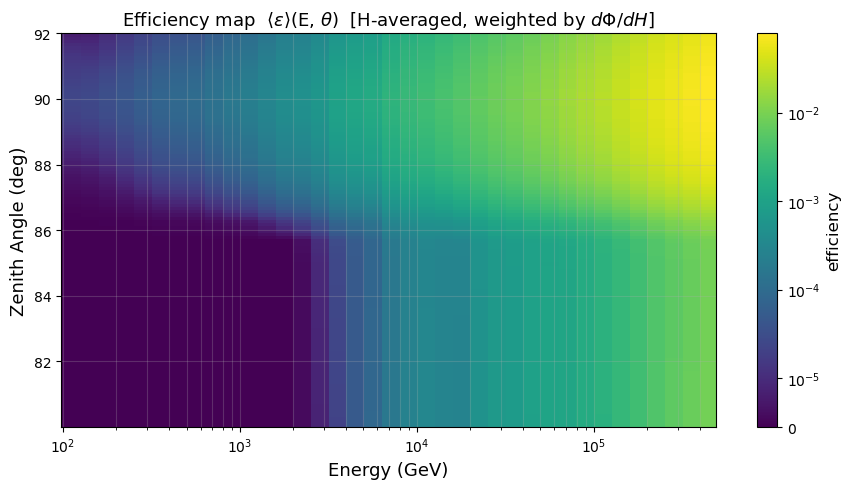

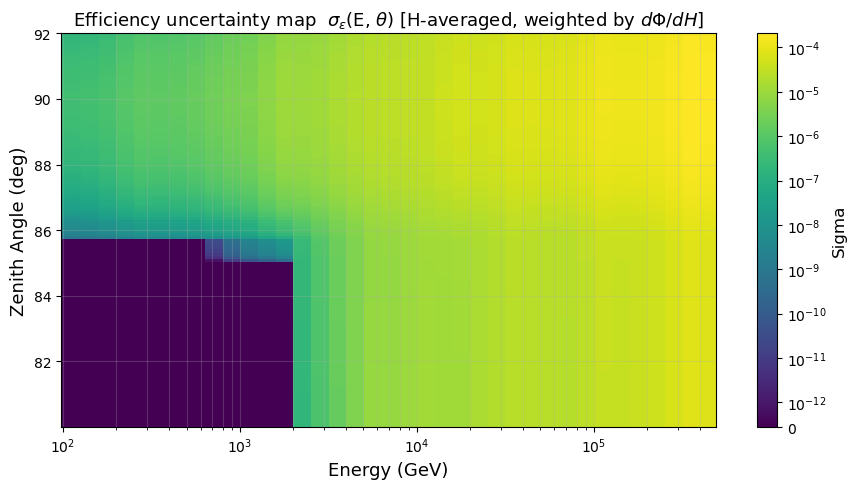

In [46]:
from matplotlib.colors import SymLogNorm

fig, ax = plt.subplots(figsize=(9, 5))
E_mask_plot = (E_GeV > 1e2) & (E_GeV < 5e5)
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    eff_map[:, E_mask_plot],
    shading='auto',
    cmap='viridis',
    norm=SymLogNorm(linthresh=np.min(eff_map[np.where(eff_map>1e-5)]), linscale=0.5, vmin=None, vmax=None, base=10),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
#ax.set_xlim(1e2, 7e5)
ax.set_title(r'Efficiency map  $\langle\varepsilon\rangle$(E, $\theta$)  '
             r'[H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('efficiency', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# --- Uncertainty heat map ---
fig, ax = plt.subplots(figsize=(9, 5))
err_map = (eff_map_err)[:, E_mask_plot]
err_min = np.nanmin(err_map)
if (not np.isfinite(err_min)) or err_min <= 0:
    err_min = 1e-12
pcm_err = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    err_map,
    shading='auto',
    cmap='viridis',
    norm=SymLogNorm(linthresh=err_min, linscale=0.5, vmin=None, vmax=None, base=10),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency uncertainty map  $\sigma_\varepsilon$(E, $\theta$) '
             r'[H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
cbar = fig.colorbar(pcm_err, ax=ax)
cbar.set_label('Sigma', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

In [50]:
import pickle

E_save_mask = (E_GeV >= 1e1) & (E_GeV <= 5e5)

eff_map_output = {
    'zen_centers': zen_centers,
    'E_GeV':       E_GeV[E_save_mask],
    'H_grid':      selected_entries[0]['H_grid'],
    'eff_map':     eff_map[:, E_save_mask],
    'eff_map_err': eff_map_err[:, E_save_mask],
    'min_E':       1e2,
    'max_E':       5e5,
    'zen_range':   (zen_min_use, zen_max_use),
    'extend_to_deg': extend_to_deg,
}

out_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(eff_map_output, f)

print(f"Saved eff_map to {out_path}")
print(f"  E range:           {E_GeV[E_save_mask].min():.1e} – {E_GeV[E_save_mask].max():.1e} GeV  ({E_save_mask.sum()} bins)")
print(f"  eff_map shape:     {eff_map[:, E_save_mask].shape}")
print(f"  eff_map_err shape: {eff_map_err[:, E_save_mask].shape}")


Saved eff_map to /uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl
  E range:           1.1e+01 – 4.5e+05 GeV  (47 bins)
  eff_map shape:     (120, 47)
  eff_map_err shape: (120, 47)


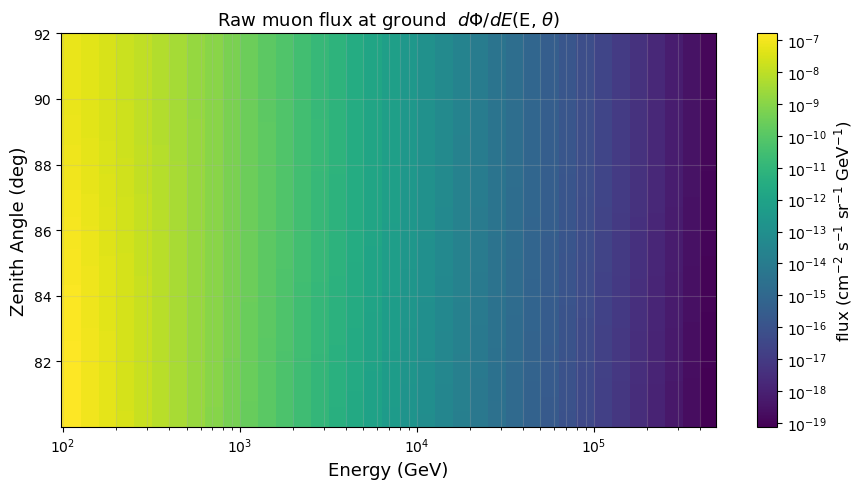

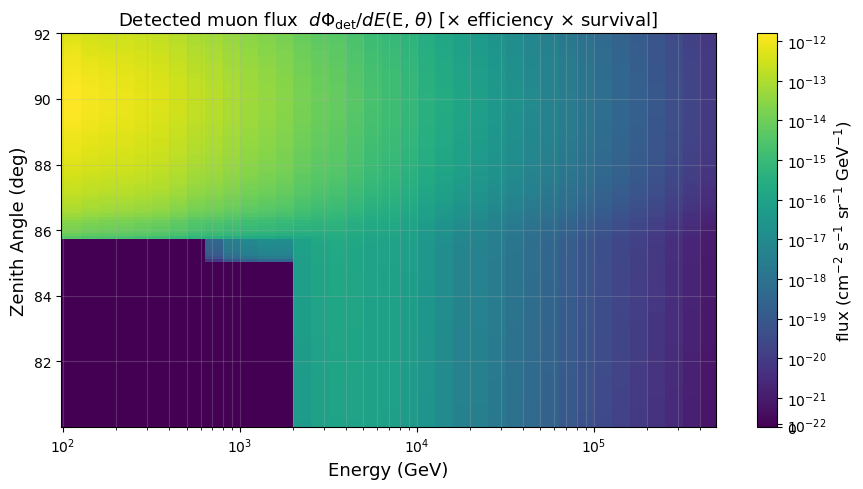

In [48]:
# =========================================================================
# Build (zenith, E) flux maps: raw and detected
# =========================================================================
flux_raw_map      = np.full((len(selected_entries), len(E_GeV)), np.nan)
flux_detected_map = np.full((len(selected_entries), len(E_GeV)), np.nan)

for i, entry in enumerate(selected_entries):
    d_CDF  = entry['d_CDF']                    # shape (nH, nE)
    H_grid = entry['H_grid']
    H_m    = H_grid / 100.0
    theta  = entry['theta']
    theta_q = min(theta, Zen_grid[-1])

    # Raw differential flux at ground: integral over H of d_CDF
    # (cumsum[-1] equals total flux per E)
    flux_raw_map[i, :] = np.cumsum(d_CDF, axis=0)[-1]

    # Detected: weight by efficiency and survival, then integrate over H
    H_mesh, E_mesh = np.meshgrid(H_m, E_GeV, indexing='ij')
    Z_mesh  = np.full_like(H_mesh, theta_q)
    eff_HE  = np.nan_to_num(eff_func(E_mesh, H_mesh, Z_mesh), nan=0.0)

    CDF          = np.cumsum(d_CDF, axis=0)
    CDF_positive = np.cumsum(np.clip(d_CDF, 0, None), axis=0)
    survival_prob_per_E = CDF[-1] / CDF_positive[-1]

    integrand = np.clip(d_CDF, 0, None) * eff_HE * survival_prob_per_E
    flux_detected_map[i, :] = np.cumsum(integrand, axis=0)[-1]

# =========================================================================
# Plot: raw muon flux map
# =========================================================================
E_mask_plot = (E_GeV > 1e2) & (E_GeV < 5e5)

fig, ax = plt.subplots(figsize=(9, 5))
raw_plot = flux_raw_map[:, E_mask_plot]
pos = raw_plot[raw_plot > 0]
lin_raw = pos.min() if pos.size else 1e-20
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    raw_plot,
    shading='auto',
    cmap='viridis',
    norm=SymLogNorm(linthresh=lin_raw, linscale=0.5, base=10),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Raw muon flux at ground  $d\Phi/dE$(E, $\theta$)', fontsize=13)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r'flux (cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$)', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# Plot: detected muon flux map (× efficiency × survival)
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
det_plot = flux_detected_map[:, E_mask_plot]
pos = det_plot[det_plot > 0]
lin_det = pos.min() if pos.size else 1e-20
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    det_plot,
    shading='auto',
    cmap='viridis',
    norm=SymLogNorm(linthresh=lin_det, linscale=0.5, base=10),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Detected muon flux  $d\Phi_{\rm det}/dE$(E, $\theta$) '
             r'[× efficiency × survival]', fontsize=13)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r'flux (cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$)', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()


Zenith bins: 120  (91.95° → 80.05°)
Energy bins: 47  (1.12e+01 → 4.47e+05 GeV)
eff_map shape: (120, 47)


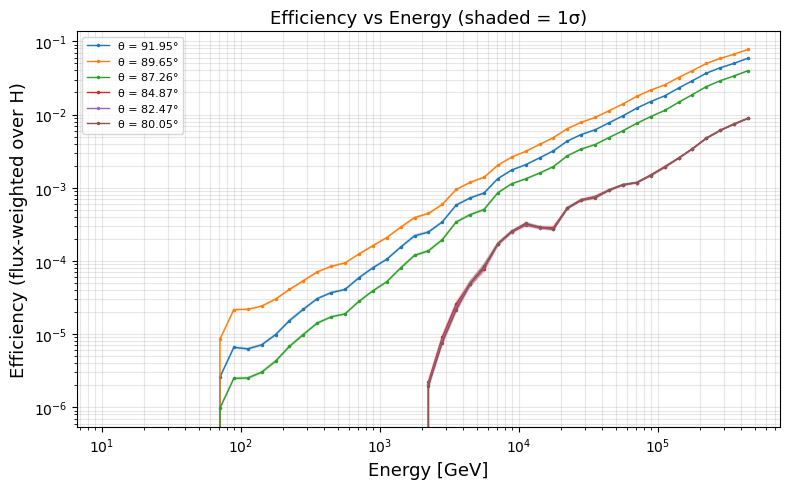

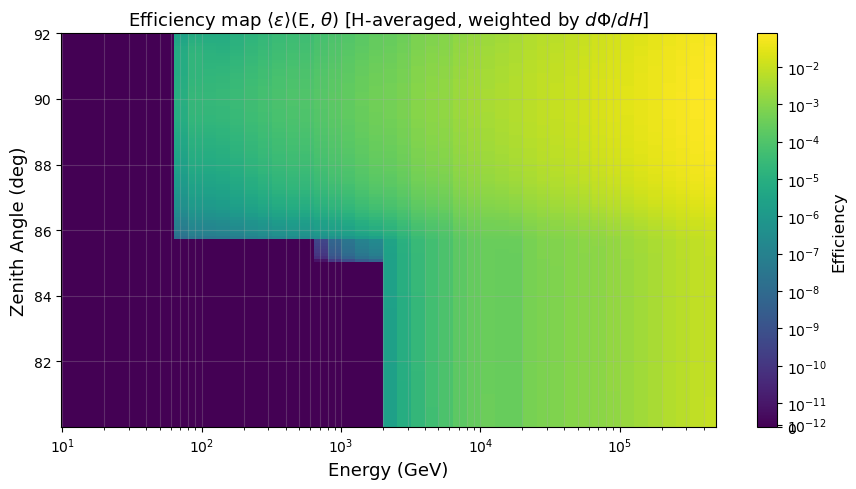

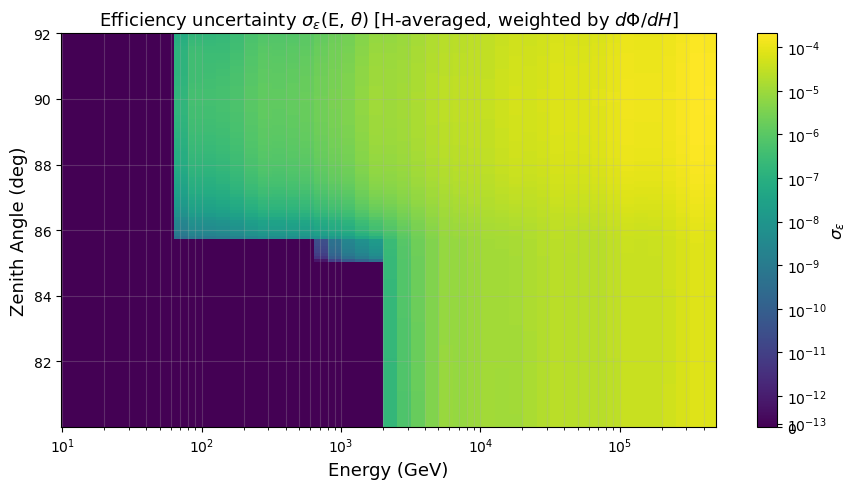

/tmp/ipykernel_828721/1490673916.py:92: RuntimeWarning: invalid value encountered in divide
  rel_err = np.where(eff_map > 0, eff_map_err / eff_map, np.nan)


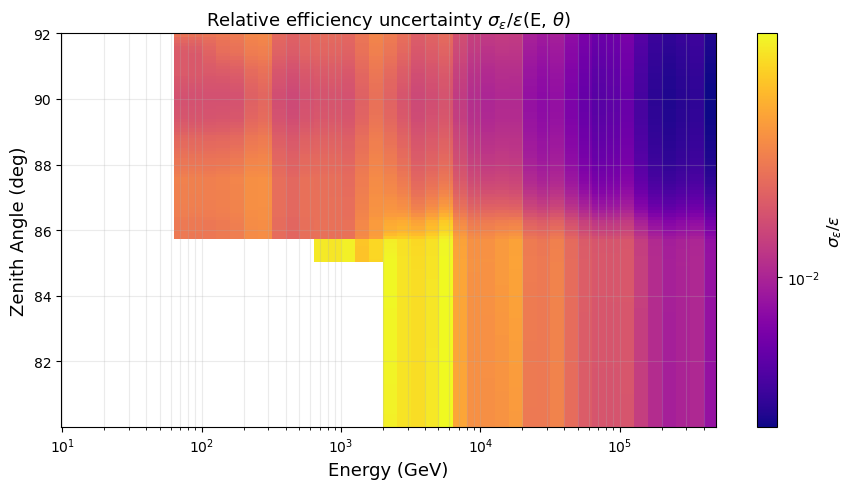

In [51]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

in_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'

with open(in_path, 'rb') as f:
    data = pickle.load(f)

zen_centers = data['zen_centers']
E_GeV       = data['E_GeV']
eff_map     = data['eff_map']
eff_map_err = data['eff_map_err']

print(f"Zenith bins: {len(zen_centers)}  ({zen_centers[0]:.2f}° → {zen_centers[-1]:.2f}°)")
print(f"Energy bins: {len(E_GeV)}  ({E_GeV[0]:.2e} → {E_GeV[-1]:.2e} GeV)")
print(f"eff_map shape: {eff_map.shape}")

# =========================================================================
# 1. Efficiency vs Energy (line plot with error bands)
# =========================================================================
fig, ax = plt.subplots(figsize=(8, 5))
n_show = min(6, len(zen_centers))
idxs = np.linspace(0, len(zen_centers) - 1, n_show, dtype=int)
for i in idxs:
    line = ax.plot(E_GeV, eff_map[i],
                   marker='.', markersize=3, linewidth=1,
                   label=f"θ = {zen_centers[i]:.2f}°")[0]
    lo = np.clip(eff_map[i] - eff_map_err[i], 0, None)
    hi = eff_map[i] + eff_map_err[i]
    ax.fill_between(E_GeV, lo, hi, color=line.get_color(), alpha=0.2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Energy [GeV]', fontsize=13)
ax.set_ylabel('Efficiency (flux-weighted over H)', fontsize=13)
ax.set_title('Efficiency vs Energy (shaded = 1σ)', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

# =========================================================================
# 2. Efficiency 2D heatmap
# =========================================================================
pos_eff = eff_map[eff_map > 0]
lin_eff = pos_eff.min() if pos_eff.size else 1e-12

fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV, zen_centers, eff_map,
    shading='auto', cmap='viridis',
    norm=SymLogNorm(linthresh=lin_eff, linscale=0.5, base=10),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency map $\langle\varepsilon\rangle$(E, $\theta$) '
             r'[H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('Efficiency', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 3. Efficiency uncertainty 2D heatmap
# =========================================================================
pos_err = eff_map_err[eff_map_err > 0]
lin_err = pos_err.min() if pos_err.size else 1e-12

fig, ax = plt.subplots(figsize=(9, 5))
pcm_err = ax.pcolormesh(
    E_GeV, zen_centers, eff_map_err,
    shading='auto', cmap='viridis',
    norm=SymLogNorm(linthresh=lin_err, linscale=0.5, base=10),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency uncertainty $\sigma_\varepsilon$(E, $\theta$) '
             r'[H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
cbar = fig.colorbar(pcm_err, ax=ax)
cbar.set_label(r'$\sigma_\varepsilon$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 4. Relative uncertainty 2D heatmap  (sigma / eff)
# =========================================================================
rel_err = np.where(eff_map > 0, eff_map_err / eff_map, np.nan)
pos_rel = rel_err[np.isfinite(rel_err) & (rel_err > 0)]
lin_rel = pos_rel.min() if pos_rel.size else 1e-3

fig, ax = plt.subplots(figsize=(9, 5))
pcm_rel = ax.pcolormesh(
    E_GeV, zen_centers, rel_err,
    shading='auto', cmap='plasma',
    norm=SymLogNorm(linthresh=lin_rel, linscale=0.5, base=10),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Relative efficiency uncertainty $\sigma_\varepsilon / \varepsilon$(E, $\theta$)',
             fontsize=13)
cbar = fig.colorbar(pcm_rel, ax=ax)
cbar.set_label(r'$\sigma_\varepsilon / \varepsilon$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()
